# 10v5_02 (v5.3) — test_simulated_strict scaling (1k / 3k / 10k) + final spectrum freeze

Protocol discovery is finished. **Primary protocol: `test_simulated_strict`.** There is no
blanket source exclusion; T1 and T2 are excluded and T3/T4 allowed. Compat ranking, top-5
selection, V1 aggregation and candidate generation are all unchanged. The 1k pilot passed its
pre-registered SCALE_GO. This notebook refuses to run unless
`outputs/v5/pilot/scale_go_decision.json` still says so for this protocol.

* **Training.** `TL_{1K,3K,10K}_TESTSIM_STRICT` are derived from the original nested manifests
  (truth in pool with at least one eligible strict reference). The originals are immutable and
  nesting is asserted.
* **Model.** The exact V1 recipe; only the training-set size changes. No tuning and no new
  feature.
* **Selection.** The full fixed TL_EVAL under strict evidence, using the pre-registered
  `casmi.ranking.scaling.V53_RULE`: highest MRR@25, with a smaller set preferred within 0.005.
  The selection is locked **before** HOST. The scale decision is 10k − 3k with a paired
  connectivity-cluster bootstrap CI.
* **HOST** confirms only. `mirror_aware` and `standard` HOST scores are labelled sensitivities.
* **Freeze.** `FROZEN` only when every pre-registered freeze condition holds; otherwise
  `PROVISIONAL` with the missing conditions listed.

Missing TL_3K/TL_10K QCR stops the notebook with a clear status table. It never falls back to 1k.
The executed v5.1 (mirror_aware `*_MODE_A`) version of this notebook is archived as
`10v5_02_scaling_and_freeze.v51_executed.ipynb`.

In [1]:
import sys, json, hashlib
from datetime import datetime, timezone
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from casmi.paths import get_project_paths
from casmi.io.parquet import load_columns
from casmi.qcr.aggregate import SPECTRAL_FEATURE_COLS, assert_no_top3_missingness_leak
from casmi.qcr.context import SEED, v4b_paths, v5_paths
from casmi.qcr.fingerprint import code_version
from casmi.qcr.protocol_features import (MISSING, READY, artifact_status, build_host_protocol_artifacts, build_protocol_artifacts, counts_path,
                                         derived_manifest_name, feature_path, qcr_status)
from casmi.qcr.protocols import (PROTOCOL_DEFS, aggregate_protocol, features_from_shards, protocol_semantic_hash, truth_evidence_ids,
                                 verify_protocol_definition_file)
from casmi.qcr.settlement import load_settlement_or_refuse
from casmi.ranking.baselines import b1, fusion
from casmi.ranking.freeze import FREEZE_CONDITIONS, feature_order_hash, freeze_status, model_file_hashes
from casmi.ranking.lambdamart import BASE_FEATURES, LGBM_PARAMS, assert_feature_list_allowed, fit_fold_models, predict_by_fold, save_fold_models
from casmi.ranking.manifests import load_manifest
from casmi.ranking.mass_likelihood import MassLikelihoodModel
from casmi.ranking.near_miss import build_near_miss_table
from casmi.ranking.rank_eval import per_query_metrics, rank_by_keys, summarize
from casmi.ranking.scaling import (POOL_BIN_EDGES, V53_MODELS, V53_NESTED_ORDER, V53_PAIRS, V53_PROTOCOL, V53_RULE, pool_size_stratification,
                                   scale_decision, score_population, select_scale_headline)
from casmi.ranking.selection import DevSelectionLock, lock_dev_selection, require_dev_selection_lock, write_preregistration
from casmi.validation.cluster_bootstrap import cluster_bootstrap_mean, paired_comparison_row
from casmi.validation.decision_log import log_decision
from casmi.validation.regime_audit import MODE_A_MIRROR, REF_ABSENT, STANDARD_ONLY, load_regimes

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 220)
paths = get_project_paths()
vp, D = v4b_paths(paths), v5_paths(paths)
PROTOCOL = V53_PROTOCOL
PDEF = PROTOCOL_DEFS[PROTOCOL]
N_BOOT, K_STRESS, KEY = 2000, (1, 3, 5), 'candidate_connectivity_key'
EXPECTED_V1_FEATURES = ['abs_mass_error_ppm', 'cosine_max', 'cosine_top3_mean', 'modified_cosine_max', 'modified_cosine_top3_mean',
                        'peak_overlap_frac_max', 'peak_overlap_frac_top3_mean', 'neutral_loss_cosine_max', 'neutral_loss_cosine_top3_mean']
PREREG = D['freeze'] / f'preregistration_v5_3__{PROTOCOL}.json'
RESULTS = {'tl_eval': {}, 'host': {}, 'oof': {}}
FREEZE_EVIDENCE = {}


def jdump(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2, default=str), encoding='utf-8')

## 0. Preconditions: SCALE_GO gate, protocol artifact, pre-registration (before any metric)

In [2]:
settlement = load_settlement_or_refuse(vp.settlement_json)
ARTS, EVID = settlement['evidence_artifacts'], settlement['evidence_fingerprint']
GO_PATH = D['root'] / 'pilot' / 'scale_go_decision.json'
if not GO_PATH.exists():
    raise RuntimeError('scaling is gated: run 10v5_05_test_simulated_1k_pilot.ipynb first (no scale_go_decision.json)')
GO = json.loads(GO_PATH.read_text(encoding='utf-8'))
if GO.get('next_step') != 'RUN_3K_10K_SCALING' or GO.get('selected_protocol') != PROTOCOL:
    raise RuntimeError(f"scaling is gated: SCALE_GO next_step={GO.get('next_step')!r}, selected_protocol={GO.get('selected_protocol')!r}, PROTOCOL={PROTOCOL!r}")
ok, why = verify_protocol_definition_file(D['root'] / 'protocols' / 'test_simulated_definition.json', PROTOCOL)
FREEZE_EVIDENCE['protocol_artifact_valid'] = bool(ok)
print('protocol artifact:', 'VALID' if ok else f'INVALID ({why})')
assert ok, why
PROTOCOL_HASH = protocol_semantic_hash(PROTOCOL)
FREEZE_EVIDENCE['protocol_hash_persisted'] = bool(PROTOCOL_HASH)
prereg = write_preregistration(PREREG, rule=V53_RULE, extra={'protocol_hash': PROTOCOL_HASH, 'lgbm_params': LGBM_PARAMS, 'features': BASE_FEATURES,
                                                             'seed': SEED, 'n_boot': N_BOOT, 'pool_bin_edges': [str(e) for e in POOL_BIN_EDGES]})
print('protocol:', PROTOCOL, '| protocol hash:', PROTOCOL_HASH, '| v5.3 rule sha256:', prereg['rule_sha256'])

protocol artifact: VALID
protocol: test_simulated_strict | protocol hash: e5ceb4e222b4a35b5937e196 | v5.3 rule sha256: d011b159a743062b02cbaa39b1d7a15a6bccf2a74fe23776a4029ef4ca4eb572


## 1. Artifact readiness. Existing QCR is reused; protocol features are derived by filter + aggregate only.

```bash
PYTHONPATH=src PYTHONNOUSERSITE=1 python scripts/v5_build_scale_features.py --manifest TL_3K      # QCR, only if MISSING
PYTHONPATH=src PYTHONNOUSERSITE=1 python scripts/v5_build_scale_features.py --manifest TL_10K     # QCR, only if MISSING
PYTHONPATH=src PYTHONNOUSERSITE=1 python scripts/v5_build_protocol_features.py --manifest TL_1K TL_3K TL_10K TL_EVAL HOST
```
This cell derives any missing protocol features itself when the QCR is ready.

In [3]:
TRAIN_BASES = ('TL_1K', 'TL_3K', 'TL_10K')
status_rows = []
for name in (*TRAIN_BASES, 'TL_EVAL'):
    q = qcr_status(D, name)
    if q == READY and artifact_status(D, name, PROTOCOL, EVID) != READY:
        print(build_protocol_artifacts(D, name, PROTOCOL, EVID, derive_training_manifest=name in TRAIN_BASES))
    elif q == READY and name in TRAIN_BASES and not (D['manifests'] / f'{derived_manifest_name(name, PROTOCOL)}.parquet').exists():
        print(build_protocol_artifacts(D, name, PROTOCOL, EVID, derive_training_manifest=True))
    status_rows.append({'dataset': name, 'QCR': q, 'features': artifact_status(D, name, PROTOCOL, EVID)})
host_q = pd.read_parquet(vp.host_processed / 'host_holdout_spectra.parquet')
if artifact_status(D, 'HOST', PROTOCOL, EVID) != READY:
    print(build_host_protocol_artifacts(D, ARTS, host_q, PROTOCOL, EVID))
status_rows.append({'dataset': 'HOST', 'QCR': READY, 'features': artifact_status(D, 'HOST', PROTOCOL, EVID)})
status = pd.DataFrame(status_rows).set_index('dataset')
for name, r in status.iterrows():
    print(f'{name} QCR: {r["QCR"]}   {name} features: {r["features"]}')
if (status == MISSING).any().any():
    raise RuntimeError('Build missing scaling artifacts before model training.')

TL_1K QCR: READY   TL_1K features: READY
TL_3K QCR: READY   TL_3K features: READY
TL_10K QCR: READY   TL_10K features: READY
TL_EVAL QCR: READY   TL_EVAL features: READY
HOST QCR: READY   HOST features: READY


## 2. Derived training manifests: nesting, leakage, retention

In [4]:
TL_MAN, _ = load_manifest('TL_EVAL', D['manifests'])
MAN, MAN_META, RET = {}, {}, []
for base in TRAIN_BASES:
    dname = derived_manifest_name(base, PROTOCOL)
    MAN[base], MAN_META[base] = load_manifest(dname, D['manifests'])
    orig, _ = load_manifest(base, D['manifests'])
    assert set(MAN[base]['query_id']) <= set(orig['query_id']), f'{dname} is not a subset of {base}'
    assert not (set(MAN[base]['connectivity_key']) & set(TL_MAN['connectivity_key'])), f'{dname}: TL_EVAL connectivity leak'
    assert not (set(MAN[base]['connectivity_key']) & set(host_q['true_connectivity_key'])), f'{dname}: HOST connectivity leak'
    counts = pd.read_parquet(counts_path(D, base, PROTOCOL))
    assert set(MAN[base]['query_id']) <= truth_evidence_ids(counts), f'{dname}: a query without a strict truth reference'
    RET.append({'manifest': dname, 'original_queries': len(orig), 'retained_queries': len(MAN[base]), 'retention_rate': len(MAN[base]) / len(orig),
                'unique_connectivities': MAN[base]['connectivity_key'].nunique(), 'manifest_sha256': MAN_META[base]['manifest_sha256']})
for a, b in zip(TRAIN_BASES[:-1], TRAIN_BASES[1:]):
    assert set(MAN[a]['query_id']) <= set(MAN[b]['query_id']), f'{a}_TESTSIM_STRICT is not nested in {b}_TESTSIM_STRICT'
FREEZE_EVIDENCE['training_manifests_persisted'] = all((D['manifests'] / f'{derived_manifest_name(b, PROTOCOL)}.parquet').exists() for b in TRAIN_BASES)
retention = pd.DataFrame(RET)
retention.to_csv(D['metrics'] / 'v53_training_retention.csv', index=False)
display(retention)

,manifest,original_queries,retained_queries,retention_rate,unique_connectivities,manifest_sha256
0,TL_1K_TESTSIM_STRICT,1000,1000,1.000000,996,1df919aea313c8c8c6bc8f4d7405d61f08273a6c617c5e...
1,TL_3K_TESTSIM_STRICT,3000,2995,0.998333,2968,57d979b737b9eb4a2078f2dc3e4e006d8bdb0ef1959df5...
2,TL_10K_TESTSIM_STRICT,10000,9989,0.998900,9711,8906d88ac9d29d166f272b43751de3ae0c49723f19f90c...


## 3. Feature contract (exact V1; audit columns never enter the model; top3_mean contract)

In [5]:
assert BASE_FEATURES == EXPECTED_V1_FEATURES, f'V1 feature list changed: {BASE_FEATURES}'
assert_feature_list_allowed(BASE_FEATURES)
FEATS = {base: pd.read_parquet(feature_path(D, base, PROTOCOL)) for base in TRAIN_BASES}
TL = pd.read_parquet(feature_path(D, 'TL_EVAL', PROTOCOL))
HOSTF = pd.read_parquet(feature_path(D, 'HOST', PROTOCOL))
for name, df in [*FEATS.items(), ('TL_EVAL', TL), ('HOST', HOSTF)]:
    assert_no_top3_missingness_leak(df)
    assert all(c in df.columns for c in BASE_FEATURES), f'{name}: missing V1 feature columns'
audit_cols = sorted(set(TL.columns) - set(BASE_FEATURES))
print('audit / id columns present in the tables but excluded from the model:', audit_cols)
FREEZE_EVIDENCE['feature_contract_validated'] = True       # reached only if every assertion above passed

audit / id columns present in the tables but excluded from the model: ['adduct', 'candidate_connectivity_key', 'fold', 'has_reference_spectrum', 'instrument', 'is_true_candidate', 'n_reference_spectra', 'query_id', 'source', 'true_connectivity_key']


## 4. Train exact V1 at 1k / 3k / 10k. An identical persisted model is reused; otherwise train.

In [6]:
CODE_VERSION = code_version()
PARAMS_HASH = hashlib.sha256(json.dumps(LGBM_PARAMS, sort_keys=True).encode()).hexdigest()[:16]
FEAT_HASH = feature_order_hash(BASE_FEATURES)


def reusable(model_dir, expected):
    meta_p = Path(model_dir) / 'model_meta.json'
    if not meta_p.exists() or len(list(Path(model_dir).glob('fold_*.txt'))) != 5:
        return False
    meta = json.loads(meta_p.read_text(encoding='utf-8'))
    return all(meta.get(k) == v for k, v in expected.items())


from casmi.ranking.lambdamart import load_fold_models
MODELS, N_TRAIN, REUSED = {}, {}, {}
for mid, dname in V53_MODELS.items():
    base = dname.replace('_TESTSIM_STRICT', '')
    tr = FEATS[base][FEATS[base]['query_id'].isin(set(MAN[base]['query_id']))]
    expected = {'model_id': mid, 'training_manifest_hash': MAN_META[base]['manifest_sha256'], 'protocol': PROTOCOL, 'protocol_hash': PROTOCOL_HASH,
                'feature_order_hash': FEAT_HASH, 'lgbm_params_hash': PARAMS_HASH, 'code_version': CODE_VERSION, 'evidence_fingerprint': EVID}
    out = D['models'] / mid
    if reusable(out, expected):
        MODELS[mid], _ = load_fold_models(out)
        REUSED[mid] = True
    else:
        folds = sorted(tr['fold'].unique())
        assert len(folds) == 5, f'{mid}: expected 5 connectivity folds, got {folds}'
        models, fold_audit = fit_fold_models(tr, BASE_FEATURES, fold_col='fold', folds=folds, params=LGBM_PARAMS)
        fold_assign = tr[['query_id', 'true_connectivity_key', 'fold']].drop_duplicates('query_id').sort_values('query_id')
        out.mkdir(parents=True, exist_ok=True)
        fold_assign.to_parquet(out / 'fold_assignments.parquet', index=False)
        save_fold_models(models, out, BASE_FEATURES, LGBM_PARAMS, tr['query_id'].unique(), extra={
            **expected, 'feature_names': BASE_FEATURES, 'lgbm_params': LGBM_PARAMS, 'seed': SEED, 'created_at': datetime.now(timezone.utc).isoformat(),
            'fold_assignments_sha256': hashlib.sha256(fold_assign.to_csv(index=False).encode()).hexdigest(),
            'fold_audit': fold_audit.to_dict('records'), 'recipe': V53_RULE['recipe']})
        (out / 'feature_names.json').write_text(json.dumps(BASE_FEATURES), encoding='utf-8')
        oof = tr[['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate', 'fold']].assign(score=predict_by_fold(models, tr, BASE_FEATURES).to_numpy())
        oof.to_parquet(out / 'oof_rows.parquet', index=False)
        MODELS[mid] = models
        REUSED[mid] = False
    oofp = out / 'oof_rows.parquet'
    if oofp.exists():   # training diagnostic only (own population), never the scaling metric
        oof = pd.read_parquet(oofp)
        RESULTS['oof'][mid] = summarize(per_query_metrics(rank_by_keys(oof, [('score', False), ('abs_mass_error_ppm', True), (KEY, True)]),
                                                          MAN[base]['query_id'].tolist()))
    N_TRAIN[mid] = int(MAN[base]['query_id'].nunique())
print({m: ('REUSED' if r else 'TRAINED') for m, r in REUSED.items()}, N_TRAIN)

{'V1_TL_1K_TESTSIM_STRICT': 'TRAINED', 'V1_TL_3K_TESTSIM_STRICT': 'TRAINED', 'V1_TL_10K_TESTSIM_STRICT': 'TRAINED'} {'V1_TL_1K_TESTSIM_STRICT': 1000, 'V1_TL_3K_TESTSIM_STRICT': 2995, 'V1_TL_10K_TESTSIM_STRICT': 9989}


# SELECTION PHASE: fixed TL_EVAL only

## 5. Common TL_EVAL scoring (fold-mean) + B1 mass-only + frozen B5 on strict evidence

In [7]:
TL_IDS = TL_MAN['query_id'].tolist()
CLUSTER_TL = TL_MAN.set_index('query_id')['connectivity_key'].to_dict()
TL_REG = load_regimes('TL_EVAL', D['root'] / 'regimes')
TL_COUNTS = pd.read_parquet(counts_path(D, 'TL_EVAL', PROTOCOL))
EVIDENCE_IDS = truth_evidence_ids(TL_COUNTS)
POPS = {'TL_EVAL_ALL': TL_IDS,
        'historical MODE_A_MIRROR': TL_REG.loc[TL_REG['regime'] == MODE_A_MIRROR, 'query_id'].tolist(),
        'STANDARD_ONLY': TL_REG.loc[TL_REG['regime'] == STANDARD_ONLY, 'query_id'].tolist(),
        'REF_ABSENT': TL_REG.loc[TL_REG['regime'] == REF_ABSENT, 'query_id'].tolist()}
coverage = {'n_truth_with_strict_reference': len(EVIDENCE_IDS & set(TL_IDS)), 'share': len(EVIDENCE_IDS & set(TL_IDS)) / len(TL_IDS)}
print('TL_EVAL truths with >=1 eligible test_simulated_strict reference (diagnostic, not a filter):', coverage)

v4b_lock = json.loads((vp.out / 'dev_selection_lock.json').read_text(encoding='utf-8'))
B5_ALPHA, B5_STD = float(v4b_lock['alphas']['B5']), v4b_lock['dev_standardizer']
mass_model = MassLikelihoodModel.from_dict(json.loads((vp.out / 'metrics' / 'mass_likelihood_model.json').read_text(encoding='utf-8')))


def with_mass_loglik(df):
    d = df.rename(columns={'instrument': 'instrument_type'})
    return d.assign(mass_loglik=mass_model.loglik(d)[0])


PQ = {mid: score_population(models, TL, BASE_FEATURES, TL_IDS)[0] for mid, models in MODELS.items()}
PQ['B1_mass'] = b1(TL, TL_IDS)
PQ['B5_frozen_v4b_testsim'] = fusion(with_mass_loglik(TL), TL_IDS, 'modified_cosine_max', B5_ALPHA, B5_STD)
rows = []
for m, pq in PQ.items():
    pq.to_parquet(D['metrics'] / f'v53_tl_eval_per_query_{m}.parquet', index=False)
    for pop, ids in POPS.items():
        rows.append({'model': m, 'population': pop, 'n_train_queries': N_TRAIN.get(m), **summarize(pq[pq['query_id'].isin(set(ids))])})
    RESULTS['tl_eval'][m] = summarize(pq)
final_table = pd.DataFrame(rows)
final_table.to_csv(D['metrics'] / 'final_model_table.csv', index=False)
curve = pd.DataFrame([{'model': m, 'n_train_queries': N_TRAIN[m], **RESULTS['tl_eval'][m]} for m in V53_NESTED_ORDER])
curve.to_csv(D['metrics'] / 'scaling_curve.csv', index=False)
display(curve)
display(final_table.pivot_table(index='model', columns='population', values='mrr_at_25').round(4))

TL_EVAL truths with >=1 eligible test_simulated_strict reference (diagnostic, not a filter): {'n_truth_with_strict_reference': 998, 'share': 0.998}


,model,n_train_queries,n_queries,n_with_candidates,mrr_at_25,hit_at_1,hit_at_5,hit_at_25
0,V1_TL_1K_TESTSIM_STRICT,1000,1000,1000,0.967136,0.951,0.986,0.997
1,V1_TL_3K_TESTSIM_STRICT,2995,1000,1000,0.966905,0.949,0.989,0.995
2,V1_TL_10K_TESTSIM_STRICT,9989,1000,1000,0.970124,0.955,0.988,0.996


population,REF_ABSENT,STANDARD_ONLY,TL_EVAL_ALL,historical MODE_A_MIRROR
model,,,,
B1_mass,0.1250,0.1408,0.1418,0.2129
B5_frozen_v4b_testsim,0.0000,0.8031,0.8023,0.8609
V1_TL_10K_TESTSIM_STRICT,0.1000,0.9724,0.9701,0.9375
V1_TL_1K_TESTSIM_STRICT,0.2083,0.9691,0.9671,0.9365
V1_TL_3K_TESTSIM_STRICT,0.1250,0.9690,0.9669,0.9375


## 6. Connectivity-cluster bootstrap. Every paired delta uses the same cluster resamples (same seed, same query set).

In [8]:
tl_ci = pd.DataFrame([{'model': m, **cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(CLUSTER_TL).to_numpy(), n_boot=N_BOOT, seed=SEED)}
                      for m, pq in PQ.items()])
pairwise = pd.DataFrame([paired_comparison_row(a, PQ[a], b, PQ[b], CLUSTER_TL, n_boot=N_BOOT, seed=SEED) for a, b in V53_PAIRS])
tl_ci.to_csv(D['bootstrap'] / 'v53_tl_eval_ci.csv', index=False)
pairwise.to_csv(D['bootstrap'] / 'scale_pairwise.csv', index=False)
display(tl_ci[['model', 'mean', 'ci_low', 'ci_high', 'n_clusters']])
display(pairwise[['comparison', 'delta', 'ci_low', 'ci_high', 'excludes_zero', 'n_clusters']])

,model,mean,ci_low,ci_high,n_clusters
0,V1_TL_1K_TESTSIM_STRICT,0.967136,0.957024,0.976069,1000
1,V1_TL_3K_TESTSIM_STRICT,0.966905,0.956735,0.975803,1000
2,V1_TL_10K_TESTSIM_STRICT,0.970124,0.960655,0.978592,1000
3,B1_mass,0.141757,0.127374,0.156485,1000
4,B5_frozen_v4b_testsim,0.802337,0.782063,0.820724,1000


,comparison,delta,ci_low,ci_high,excludes_zero,n_clusters
0,V1_TL_3K_TESTSIM_STRICT vs V1_TL_1K_TESTSIM_ST...,-0.000231,-0.005049,0.004854,False,1000
1,V1_TL_10K_TESTSIM_STRICT vs V1_TL_3K_TESTSIM_S...,0.003219,-0.001097,0.007517,False,1000
2,V1_TL_10K_TESTSIM_STRICT vs V1_TL_1K_TESTSIM_S...,0.002988,-0.001740,0.007925,False,1000


## 7. Pre-registered scale decision (10k − 3k) + headline selection → **LOCK** before HOST

In [9]:
paired = {(r['model_a'], r['model_b']): r for r in pairwise.to_dict('records')}
decision = scale_decision(paired, set(MODELS), nested_order=V53_NESTED_ORDER)
sel_in = pd.DataFrame([{'model_id': m, 'tl_eval_mrr': RESULTS['tl_eval'][m]['mrr_at_25'], 'n_train_queries': N_TRAIN[m], 'status': 'OK'}
                       for m in V53_NESTED_ORDER])
SELECTED, ranked = select_scale_headline(sel_in, margin=V53_RULE['headline_margin'], candidates=V53_NESTED_ORDER)
LOCK_PATH = D['freeze'] / f'selection_lock_v5_3__{PROTOCOL}.json'
lock_rec = lock_dev_selection(LOCK_PATH, SELECTED, ranked, {'B5_frozen_v4b_alpha': B5_ALPHA}, PREREG,
                              extra={'selection_population': 'TL_EVAL', 'protocol': PROTOCOL, 'protocol_hash': PROTOCOL_HASH, 'scale_decision': decision,
                                     'selector_input_columns': list(sel_in.columns)})
FREEZE_EVIDENCE['selection_on_tl_eval_only'] = (lock_rec['selection_population'] == 'TL_EVAL'
                                                and not any('host' in c.lower() for c in lock_rec['selector_input_columns']))
FREEZE_EVIDENCE['scale_decision_10k_vs_3k'] = (decision.get('pair') == ['V1_TL_10K_TESTSIM_STRICT', 'V1_TL_3K_TESTSIM_STRICT']
                                                and decision['scaling_status'] in ('CONTINUE_SCALING', 'PLATEAU'))
log_decision(decision=f"v5.3 spectrum model (TL_EVAL rule): {SELECTED}; scaling_status={decision['scaling_status']}",
             evidence_used='final_model_table.csv, scale_pairwise.csv; no HOST metric computed yet', host_visible=False,
             category='pre_registered_choice', log_path=paths.outputs / 'decision_log.jsonl')
display(ranked)
print('SCALING STATUS:', decision['scaling_status'], decision.get('pair'), '| SELECTED:', SELECTED)

,model_id,tl_eval_mrr,n_train_queries,status,contender,selection_order
0,V1_TL_1K_TESTSIM_STRICT,0.967136,1000,OK,True,1
1,V1_TL_3K_TESTSIM_STRICT,0.966905,2995,OK,True,2
2,V1_TL_10K_TESTSIM_STRICT,0.970124,9989,OK,True,3


SCALING STATUS: PLATEAU ['V1_TL_10K_TESTSIM_STRICT', 'V1_TL_3K_TESTSIM_STRICT'] | SELECTED: V1_TL_1K_TESTSIM_STRICT


# CONFIRMATION PHASE: HOST (cannot change the selection)

In [10]:
LOCK = require_dev_selection_lock(LOCK_PATH, PREREG)
assert LOCK.selected_model_id == SELECTED
HOST_IDS = host_q['query_id'].tolist()
CLUSTER_HOST = host_q.set_index('query_id')['true_connectivity_key'].to_dict()
host_meta = host_q[['query_id', 'true_connectivity_key']]


def host_eval(lock, feats):
    assert isinstance(lock, DevSelectionLock)
    pq = score_population(MODELS[lock.selected_model_id], feats, BASE_FEATURES, HOST_IDS)[0]
    ci = cluster_bootstrap_mean(pq['rr'].to_numpy(), pq['query_id'].map(CLUSTER_HOST).to_numpy(), n_boot=N_BOOT, seed=SEED)
    return pq, {**summarize(pq), 'ci_low': ci['ci_low'], 'ci_high': ci['ci_high']}


HOST_PQ, host_primary = host_eval(LOCK, HOSTF)
RESULTS['host'] = {'test_simulated_strict (primary)': host_primary}
sens = {'mirror_aware (conservative cross-library sensitivity)': pd.read_parquet(ARTS['host_features_mirror_aware']).merge(host_meta, on='query_id', how='left')}
if (feature_path(D, 'HOST', 'standard')).exists():
    sens['standard (OPTIMISTIC / DUPLICATE-PERMITTING SENSITIVITY)'] = pd.read_parquet(feature_path(D, 'HOST', 'standard'))
for label, feats in sens.items():
    RESULTS['host'][label] = host_eval(LOCK, feats)[1]
HOST_WRITTEN_AT = datetime.now(timezone.utc).isoformat()
jdump({'written_at': HOST_WRITTEN_AT, 'model': SELECTED, **RESULTS['host']}, D['metrics'] / 'v53_host_confirmation.json')
FREEZE_EVIDENCE['selection_locked_before_host'] = lock_rec['locked_at'] < HOST_WRITTEN_AT
display(pd.DataFrame(RESULTS['host']).T.round(4))

,n_queries,n_with_candidates,mrr_at_25,hit_at_1,hit_at_5,hit_at_25,ci_low,ci_high
test_simulated_strict (primary),1184.0,1184.0,0.8367,0.7627,0.9316,0.9890,0.8106,0.8626
mirror_aware (conservative cross-library sensitivity),1184.0,1184.0,0.7595,0.6512,0.8910,0.9848,0.7256,0.7912
standard (OPTIMISTIC / DUPLICATE-PERMITTING SENSITIVITY),1184.0,1184.0,0.8365,0.7627,0.9316,0.9890,0.8103,0.8621


## 8. Candidate density (selected model; fixed pool-size bins; sparse bins shown with n)

In [11]:
density = pd.concat([pool_size_stratification(PQ[SELECTED]).assign(dataset='TL_EVAL'), pool_size_stratification(HOST_PQ).assign(dataset='HOST')], ignore_index=True)
density.to_csv(D['metrics'] / 'candidate_density.csv', index=False)
display(density)

,pool_bin,n_queries,mrr,hit_at_1,median_pool,low_n,dataset
0,0-49,45,0.966667,0.955556,33.0,False,TL_EVAL
1,50-99,79,0.970954,0.962025,71.0,False,TL_EVAL
2,100-199,187,0.969930,0.962567,153.0,False,TL_EVAL
3,200-399,304,0.967285,0.947368,282.5,False,TL_EVAL
4,400-799,344,0.964531,0.944767,582.0,False,TL_EVAL
5,>=800,41,0.968293,0.951220,871.0,False,TL_EVAL
6,0-49,641,0.870618,0.797192,13.0,False,HOST
7,50-99,170,0.810160,0.729412,64.0,False,HOST
8,100-199,170,0.773535,0.705882,146.0,False,HOST
9,200-399,144,0.773479,0.687500,289.0,False,HOST


## 9. Reference-richness stress: k = 1 / 3 / 5 strict references per candidate, applied to truth and decoys alike (robustness only; not used for selection)

In [12]:
TL_SHARDS = sorted((D['qcr'] / 'TL_EVAL' / 'qcr' / 'shards').glob('part-*.parquet'))
TL_POOL = pd.read_parquet(D['features'] / 'units' / 'TL_EVAL_pool.parquet')
host_qcr = pd.read_parquet(ARTS['host_qcr'])
host_pool = HOSTF[['query_id', KEY, 'abs_mass_error_ppm', 'is_true_candidate']]
rich = []
for k in K_STRESS:
    tlk = features_from_shards(TL_SHARDS, TL_POOL, PDEF, k=k)[0]
    hk = aggregate_protocol(host_qcr, host_pool, PDEF, k=k)
    rich.append({'dataset': 'TL_EVAL', 'k': k, **summarize(score_population(MODELS[SELECTED], tlk, BASE_FEATURES, TL_IDS)[0])})
    rich.append({'dataset': 'HOST', 'k': k, **summarize(score_population(MODELS[SELECTED], hk, BASE_FEATURES, HOST_IDS)[0])})
rich = pd.DataFrame(rich)
rich.to_csv(D['metrics'] / 'reference_richness.csv', index=False)
del host_qcr
display(rich.pivot_table(index='dataset', columns='k', values='mrr_at_25').round(4))

k,1,3,5
dataset,,,
HOST,0.7519,0.8025,0.8367
TL_EVAL,0.9105,0.9617,0.9671


## 10. Near-miss / same-formula error set (truth rank 2–10; preparation only, no new features)

In [13]:
ranked_tl = score_population(MODELS[SELECTED], TL, BASE_FEATURES, TL_IDS)[1]      # candidate rows with fold-mean `score` + `rank`
sel_audit = features_from_shards(TL_SHARDS, TL_POOL, PDEF)[1].assign(_t3=lambda d: d['tier'] == 'T3')
tier_flags = sel_audit.groupby(['query_id', 'candidate_key']).agg(has_t3_accepted=('_t3', 'any'), n_t3_accepted=('_t3', 'sum')).reset_index() \
    .rename(columns={'candidate_key': KEY})
elig = TL_COUNTS.rename(columns={'n_eligible': 'eligible_reference_count'}).assign(eligible_reference_saturated=lambda d: d['count_censored'] | (d['eligible_reference_count'] >= 5))
keys_needed = set(ranked_tl.loc[ranked_tl['rank'] <= 10, KEY])
tm = load_columns(paths.processed / 'train_spectrum_metadata.parquet', ['connectivity_key', 'molecular_formula'])
formula_of_key = tm[tm['connectivity_key'].isin(keys_needed)].drop_duplicates('connectivity_key').set_index('connectivity_key')['molecular_formula'].to_dict()
del tm
st = pd.read_parquet(paths.interim / 'structure_table.parquet', columns=['connectivity_key', 'canonical_smiles'])
smiles_of_key = st[st['connectivity_key'].isin(keys_needed)].drop_duplicates('connectivity_key').set_index('connectivity_key')['canonical_smiles'].to_dict()
del st
nm = build_near_miss_table(ranked_tl, PQ[SELECTED], 'score', formula_of_key, smiles_of_key, tier_flags, elig)
near = nm[(nm['truth_rank'] > 1) & (nm['truth_rank'] <= 10)].copy()
for c in ('cosine_max', 'modified_cosine_max', 'peak_overlap_frac_max', 'neutral_loss_cosine_max'):
    near[f'delta_{c}'] = near[f'wrong_{c}'] - near[f'truth_{c}']
near.to_parquet(D['metrics'] / f'v53_near_miss_rank2_10_{SELECTED}.parquet', index=False)
print(f"near misses (truth rank 2-10): {len(near)} | same formula share: {near['same_formula'].mean() if len(near) else float('nan'):.3f}")

near misses (truth rank 2-10): 40 | same formula share: 0.825


## 11. Freeze (pre-registered conditions) + deployment protocol gap record

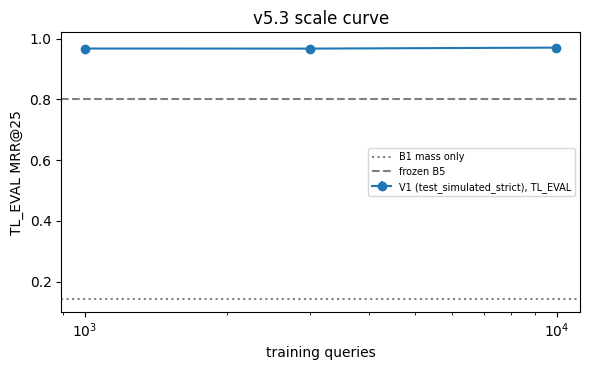

In [14]:
sel_dir = D['models'] / SELECTED
FREEZE_EVIDENCE['selected_model_artifacts_exist'] = len(list(sel_dir.glob('fold_*.txt'))) == 5 and (sel_dir / 'model_meta.json').exists()
MODEL_HASHES = model_file_hashes(sel_dir)
FREEZE_EVIDENCE['model_hashes_persisted'] = len(MODEL_HASHES) == 5
FREEZE_EVIDENCE['metrics_and_bootstrap_persisted'] = all((p).exists() for p in (
    D['metrics'] / 'scaling_curve.csv', D['metrics'] / 'final_model_table.csv', D['metrics'] / 'candidate_density.csv',
    D['metrics'] / 'reference_richness.csv', D['bootstrap'] / 'scale_pairwise.csv'))
FREEZE_STATUS, MISSING_CONDITIONS = freeze_status(FREEZE_EVIDENCE)
sel_base = V53_MODELS[SELECTED].replace('_TESTSIM_STRICT', '')
ci_of = tl_ci.set_index('model')
pw = pairwise.set_index('comparison')
freeze = {
    'freeze_status': FREEZE_STATUS, 'missing_conditions': MISSING_CONDITIONS, 'freeze_conditions': FREEZE_EVIDENCE, 'rule_version': 'v5.3',
    'selected_model_id': SELECTED, 'model_id': SELECTED, 'model_dir': str(sel_dir),
    'selected_training_manifest': V53_MODELS[SELECTED], 'manifest': V53_MODELS[SELECTED], 'manifest_hash': MAN_META[sel_base]['manifest_sha256'],
    'training_query_count': N_TRAIN[SELECTED], 'training_connectivity_count': int(MAN[sel_base]['connectivity_key'].nunique()),
    'protocol': PROTOCOL, 'protocol_hash': PROTOCOL_HASH, 'feature_names': BASE_FEATURES, 'feature_order_hash': FEAT_HASH,
    'model_files': sorted(MODEL_HASHES), 'model_hashes': MODEL_HASHES, 'selection_population': 'TL_EVAL',
    'TL_EVAL': {**RESULTS['tl_eval'][SELECTED], 'ci_low': ci_of.loc[SELECTED, 'ci_low'], 'ci_high': ci_of.loc[SELECTED, 'ci_high']},
    'TL_EVAL_truth_strict_reference_coverage': coverage,
    'scale_curve': {m: {'n_train_queries': N_TRAIN[m], **RESULTS['tl_eval'][m]} for m in V53_NESTED_ORDER},
    'paired_bootstrap': {'3k_minus_1k': pw.loc['V1_TL_3K_TESTSIM_STRICT vs V1_TL_1K_TESTSIM_STRICT', ['delta', 'ci_low', 'ci_high']].to_dict(),
                         '10k_minus_3k': pw.loc['V1_TL_10K_TESTSIM_STRICT vs V1_TL_3K_TESTSIM_STRICT', ['delta', 'ci_low', 'ci_high']].to_dict(),
                         '10k_minus_1k': pw.loc['V1_TL_10K_TESTSIM_STRICT vs V1_TL_1K_TESTSIM_STRICT', ['delta', 'ci_low', 'ci_high']].to_dict()},
    'scaling_status': decision['scaling_status'], 'scale_decision': decision,
    'HOST_confirmation': RESULTS['host'],
    'reference_richness': {f'k{r.k}_{r.dataset}': r.mrr_at_25 for r in rich.itertuples()},
    'selection_rule': V53_RULE, 'selection_rule_sha256': prereg['rule_sha256'], 'selection_lock': str(LOCK_PATH),
    'lgbm_params': LGBM_PARAMS, 'seed': SEED, 'evidence_fingerprint': EVID, 'code_version': CODE_VERSION,
    'created_at': datetime.now(timezone.utc).isoformat(),
}
jdump(freeze, D['freeze'] / 'spectrum_model.json')

bundle_cfg = json.loads((D['bundle'] / 'config.json').read_text(encoding='utf-8')) if (D['bundle'] / 'config.json').exists() else {}
tier_summary_p = D['root'] / 'provenance' / 'tier_summary.json'
prov = json.loads(tier_summary_p.read_text(encoding='utf-8')) if tier_summary_p.exists() else {}
so = (prov.get('tier_summary') or {}).get('STANDARD_ONLY', {})
gap = {'training_protocol': PROTOCOL, 'training_protocol_hash': PROTOCOL_HASH,
       'deployment_behavior': {'source': 'bundle/config.json' if bundle_cfg else 'bundle not exported', 'exclude_sources': bundle_cfg.get('exclude_sources'),
                               'identity_tiers_applied': bundle_cfg.get('identity_tiers_applied')},
       'known_gap': 'T2 enforcement: test_simulated_strict excludes T2 (tolerant mirrors); casmi_infer applies T1 via peak hash but cannot apply T2 (no identity peaks shipped)',
       'historical_T2_prevalence_from_provenance_audit': {'query_level_has_T2': (so.get('query_level') or {}).get('has_T2'),
                                                          'query_level_selected_has_T2': (so.get('query_level') or {}).get('selected_has_T2'),
                                                          'pair_level_T2_share': (so.get('pair_level_tier_share') or {}).get('T2')},
       'artifact_references': [str(tier_summary_p), str(D['root'] / 'protocols' / 'protocol_semantics.csv'), str(D['bundle'] / 'config.json')],
       'resolution_status': 'PENDING_DEPLOYMENT_PARITY_TASK', 'created_at': datetime.now(timezone.utc).isoformat()}
jdump(gap, D['freeze'] / 'deployment_protocol_gap.json')

fig, ax = plt.subplots(figsize=(6, 3.8))
xs = [N_TRAIN[m] for m in V53_NESTED_ORDER]
ax.errorbar(xs, [RESULTS['tl_eval'][m]['mrr_at_25'] for m in V53_NESTED_ORDER],
            yerr=[[RESULTS['tl_eval'][m]['mrr_at_25'] - ci_of.loc[m, 'ci_low'] for m in V53_NESTED_ORDER],
                  [ci_of.loc[m, 'ci_high'] - RESULTS['tl_eval'][m]['mrr_at_25'] for m in V53_NESTED_ORDER]], fmt='o-', label='V1 (test_simulated_strict), TL_EVAL')
ax.axhline(RESULTS['tl_eval']['B1_mass']['mrr_at_25'], color='grey', ls=':', label='B1 mass only')
ax.axhline(RESULTS['tl_eval']['B5_frozen_v4b_testsim']['mrr_at_25'], color='grey', ls='--', label='frozen B5')
ax.set_xscale('log'); ax.set_xlabel('training queries'); ax.set_ylabel('TL_EVAL MRR@25'); ax.legend(fontsize=7); ax.set_title('v5.3 scale curve')
fig.tight_layout(); fig.savefig(D['figures'] / 'scale_curve_v5_3.png', dpi=130); plt.show()

## 12. Summary (runtime-derived)

In [15]:
print('PROTOCOL:\n' + PROTOCOL)
print('\nTRAINING:')
for m in V53_NESTED_ORDER:
    print(f"{m.split('_')[2]}: {N_TRAIN[m]} retained")
print('\nTL-EVAL:')
print(f"{'model':<28}{'MRR':>8}{'Hit1':>8}{'Hit5':>8}{'Hit25':>8}")
for m in [*V53_NESTED_ORDER, 'B1_mass', 'B5_frozen_v4b_testsim']:
    r = RESULTS['tl_eval'][m]
    print(f"{m:<28}{r['mrr_at_25']:>8.4f}{r['hit_at_1']:>8.4f}{r['hit_at_5']:>8.4f}{r['hit_at_25']:>8.4f}")
print('\nPAIRED BOOTSTRAP:')
for k, v in freeze['paired_bootstrap'].items():
    print(f"{k}: {v['delta']:+.4f} [{v['ci_low']:+.4f}, {v['ci_high']:+.4f}]")
print(f"\nSCALING STATUS:\n{decision['scaling_status']}")
print(f'\nSELECTED MODEL:\n{SELECTED}')
hp = RESULTS['host']['test_simulated_strict (primary)']
print(f"\nHOST CONFIRMATION:\nMRR {hp['mrr_at_25']:.4f} [{hp['ci_low']:.4f}, {hp['ci_high']:.4f}]  Hit1 {hp['hit_at_1']:.4f}  Hit5 {hp['hit_at_5']:.4f}  Hit25 {hp['hit_at_25']:.4f}")
print(f'\nFREEZE STATUS:\n{FREEZE_STATUS}' + (f'  (missing: {MISSING_CONDITIONS})' if MISSING_CONDITIONS else ''))
print('\nNEXT:\n' + ('MOLECULE_AGGREGATION' if FREEZE_STATUS == 'FROZEN' else 'COMPLETE_MISSING_ARTIFACTS'))

PROTOCOL:
test_simulated_strict

TRAINING:
1K: 1000 retained
3K: 2995 retained
10K: 9989 retained

TL-EVAL:
model                            MRR    Hit1    Hit5   Hit25
V1_TL_1K_TESTSIM_STRICT       0.9671  0.9510  0.9860  0.9970
V1_TL_3K_TESTSIM_STRICT       0.9669  0.9490  0.9890  0.9950
V1_TL_10K_TESTSIM_STRICT      0.9701  0.9550  0.9880  0.9960
B1_mass                       0.1418  0.0580  0.2140  0.5960
B5_frozen_v4b_testsim         0.8023  0.6990  0.9250  0.9840

PAIRED BOOTSTRAP:
3k_minus_1k: -0.0002 [-0.0050, +0.0049]
10k_minus_3k: +0.0032 [-0.0011, +0.0075]
10k_minus_1k: +0.0030 [-0.0017, +0.0079]

SCALING STATUS:
PLATEAU

SELECTED MODEL:
V1_TL_1K_TESTSIM_STRICT

HOST CONFIRMATION:
MRR 0.8367 [0.8106, 0.8626]  Hit1 0.7627  Hit5 0.9316  Hit25 0.9890

FREEZE STATUS:
FROZEN

NEXT:
MOLECULE_AGGREGATION
